<a href="https://colab.research.google.com/github/sastha-06/24ADI003_ML_LAB/blob/main/24BAD106_ML_EX10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SCENARIO 1 – MATRIX FACTORIZATION USING SVD**

In this experiment, I used the MovieLens dataset to recommend movies based on user preferences. I selected features such as userId, movieId, and rating, where rating is used to understand user-item interactions. After preprocessing the dataset and splitting it into training and testing data, I created a user-item interaction matrix. Then, I applied normalization using mean centering to improve the performance of the model.

I used Singular Value Decomposition (SVD) to decompose the matrix into latent factors and reduced its dimensionality by selecting different values of k. After reconstructing the matrix, I predicted the missing ratings for unseen movies. I evaluated the model performance using RMSE and MAE metrics for different values of latent factors.

I also visualized the results using a heatmap to compare the original and reconstructed matrices, plotted error vs number of latent factors, and displayed the top recommended movies. From the results, I observed that SVD effectively captures hidden patterns in user preferences and provides accurate movie recommendations, while also reducing dimensionality and improving computational efficiency.

SASTHA JEYASRI A
24BAD106
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
k=5 → RMSE=3.0128, MAE=2.7806
k=10 → RMSE=2.9930, MAE=2.7561
k=20 → RMSE=3.0312, MAE=2.8008
k=50 → RMSE=3.1924, MAE=2.9776
k=100 → RMSE=3.3889, MAE=3.1936

Top Recommendations for User 1:
Movie ID: 858 → Predicted Rating: 0.20
Movie ID: 1221 → Predicted Rating: 0.20
Movie ID: 1374 → Predicted Rating: 0.19
Movie ID: 1954 → Predicted Rating: 0.16
Movie ID: 1256 → Predicted Rating: 0.16


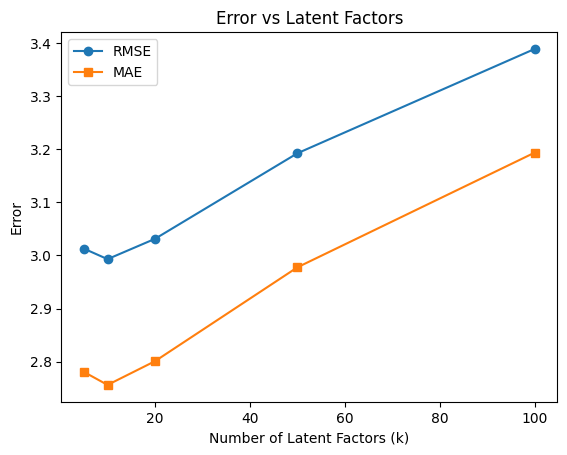

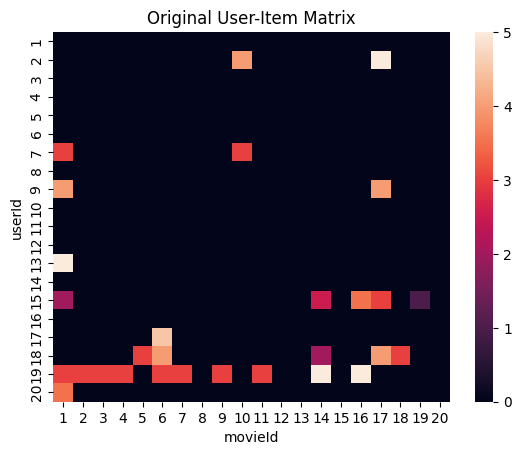

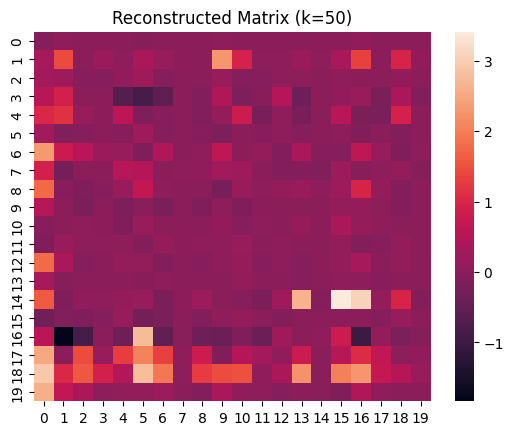

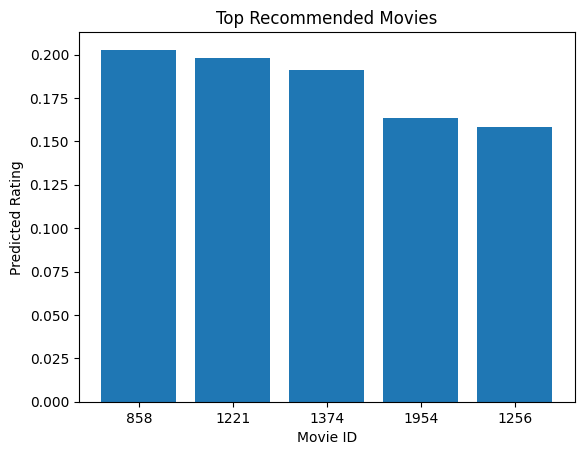

In [20]:
#from google.colab import files
#uploaded = files.upload()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import seaborn as sns

# Load dataset
df = pd.read_csv('ratings.csv')
print("SASTHA JEYASRI A\n24BAD106")
print(df.columns)

# Drop timestamp column
df = df.drop('timestamp', axis=1)

# Split into train and test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create user-item matrix using train data
user_item_matrix = train_df.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

# Normalize data (mean centering)
user_mean = np.mean(matrix_filled, axis=1)
matrix_norm = matrix_filled.sub(user_mean, axis=0)

# Different k values (latent factors)
k_values = [5, 10, 20, 50, 100]

rmse_list = []
mae_list = []
reconstructed_matrices = {}

for k in k_values:
    # Apply SVD correctly
    svd = TruncatedSVD(n_components=k, random_state=42)
    matrix_reduced = svd.fit_transform(matrix_norm)

    # Reconstruct using inverse_transform
    reconstructed = svd.inverse_transform(matrix_reduced)

    # Add mean back
    reconstructed += user_mean.values.reshape(-1, 1)

    reconstructed_matrices[k] = reconstructed

    # Evaluate using test data
    y_true = []
    y_pred = []

    for row in test_df.itertuples():
        if row.userId in matrix_filled.index and row.movieId in matrix_filled.columns:
            user_idx = matrix_filled.index.get_loc(row.userId)
            movie_idx = matrix_filled.columns.get_loc(row.movieId)
            pred = reconstructed[user_idx, movie_idx]
            y_true.append(row.rating)
            y_pred.append(pred)

    # Calculate RMSE and MAE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    rmse_list.append(rmse)
    mae_list.append(mae)

    print(f"k={k} → RMSE={rmse:.4f}, MAE={mae:.4f}")

# Recommendation function (fixed indexing)
def recommend_movies(user_id, top_n=5, k=50):
    if user_id not in matrix_filled.index:
        return []

    user_idx = matrix_filled.index.get_loc(user_id)
    preds = reconstructed_matrices[k][user_idx]

    rated_movies = matrix_filled.iloc[user_idx]
    unrated = rated_movies[rated_movies == 0].index

    scores = []
    for movie in unrated:
        movie_idx = matrix_filled.columns.get_loc(movie)
        scores.append((movie, preds[movie_idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    return scores[:top_n]

# Show recommendations
print("\nTop Recommendations for User 1:")
for movie, score in recommend_movies(1):
    print(f"Movie ID: {movie} → Predicted Rating: {score:.2f}")

# Plot error vs k
plt.figure()
plt.plot(k_values, rmse_list, marker='o', label='RMSE')
plt.plot(k_values, mae_list, marker='s', label='MAE')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("Error")
plt.title("Error vs Latent Factors")
plt.legend()
plt.show()

# Heatmap of original matrix
plt.figure()
sns.heatmap(matrix_filled.iloc[:20, :20])
plt.title("Original User-Item Matrix")
plt.show()

# Heatmap of reconstructed matrix (for k = 50)
plt.figure()
sns.heatmap(reconstructed_matrices[50][:20, :20])
plt.title("Reconstructed Matrix (k=50)")
plt.show()

# Visualization of Top Recommended Movie
recommendations = recommend_movies(1)

movies = [str(m[0]) for m in recommendations]
scores = [m[1] for m in recommendations]

plt.figure()
plt.bar(movies, scores)
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.title("Top Recommended Movies")
plt.show()


**SCENARIO 2 – MATRIX FACTORIZATION USING NMF**

In this experiment, Non-negative Matrix Factorization (NMF) was applied on the MovieLens dataset to build a recommendation system using latent features. A user-item matrix was created and missing values were filled with zero to satisfy NMF constraints.

The model factorized the matrix into user and item feature matrices, which were used to reconstruct ratings and predict missing values. Performance was evaluated using RMSE, MAE, Precision@K, and Recall@K.

Top-N recommendations were generated for users, and visualizations helped analyze model behavior. NMF proved effective for sparse data and provided interpretable latent features for better recommendations.

SASTHA JEYASRI A
24BAD106
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
k=5 → RMSE=3.0443, MAE=2.8141
k=10 → RMSE=3.0299, MAE=2.7970
k=20 → RMSE=3.0750, MAE=2.8485
k=50 → RMSE=3.1967, MAE=2.9807

Top Recommendations for User 1:
Movie ID: 912 → Predicted Rating: 0.14
Movie ID: 923 → Predicted Rating: 0.14
Movie ID: 908 → Predicted Rating: 0.12
Movie ID: 1247 → Predicted Rating: 0.12
Movie ID: 1225 → Predicted Rating: 0.12

Precision@10: 0.0000, Recall@10: 0.0000


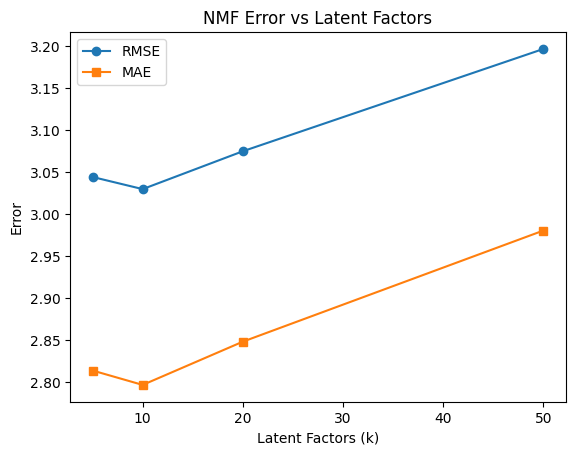

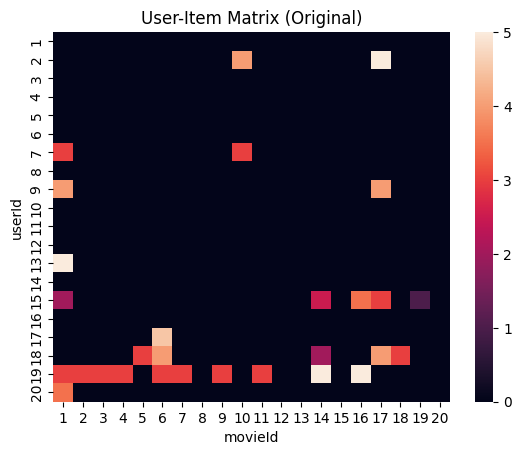

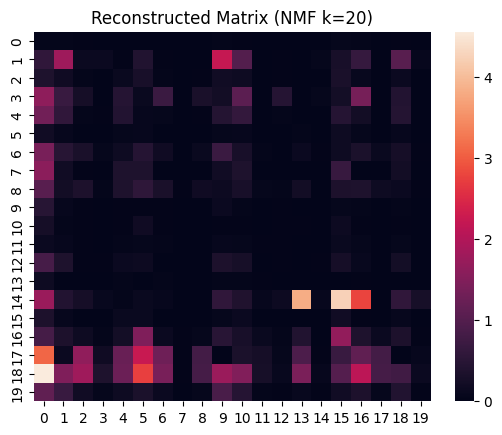

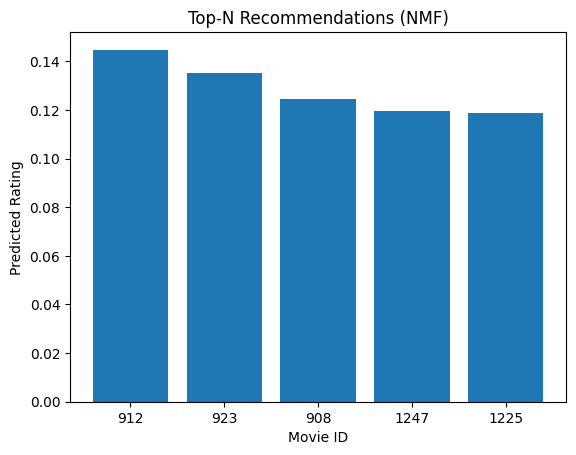

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv('ratings.csv')
print("SASTHA JEYASRI A\n24BAD106")
print(df.columns)

# Drop timestamp
df = df.drop('timestamp', axis=1)

# Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create user-item matrix
user_item_matrix = train_df.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

# Convert to numpy
R = matrix_filled.values
users = matrix_filled.index
movies = matrix_filled.columns

# Latent factors
k_values = [5, 10, 20, 50]

rmse_list = []
mae_list = []
reconstructed_matrices = {}

# NMF MODEL TRAINING
for k in k_values:

    nmf = NMF(n_components=k, init='random', random_state=42, max_iter=500)

    W = nmf.fit_transform(R)      # User-feature matrix
    H = nmf.components_           # Item-feature matrix

    R_pred = np.dot(W, H)        # Reconstructed matrix
    reconstructed_matrices[k] = R_pred

    # EVALUATION (RMSE / MAE)
    y_true = []
    y_pred = []

    for row in test_df.itertuples():
        if row.userId in users and row.movieId in movies:
            u_idx = users.get_loc(row.userId)
            i_idx = movies.get_loc(row.movieId)

            y_true.append(row.rating)
            y_pred.append(R_pred[u_idx, i_idx])

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    rmse_list.append(rmse)
    mae_list.append(mae)

    print(f"k={k} → RMSE={rmse:.4f}, MAE={mae:.4f}")


# RECOMMENDATION FUNCTION
def recommend_movies(user_id, top_n=5, k=20):

    if user_id not in users:
        return []

    u_idx = users.get_loc(user_id)
    preds = reconstructed_matrices[k][u_idx]

    rated_movies = matrix_filled.iloc[u_idx]
    unrated = rated_movies[rated_movies == 0].index

    scores = []
    for movie in unrated:
        i_idx = movies.get_loc(movie)
        scores.append((movie, preds[i_idx]))

    scores.sort(key=lambda x: x[1], reverse=True)

    return scores[:top_n]

# Example recommendations
print("\nTop Recommendations for User 1:")
for movie, score in recommend_movies(1, k=20):
    print(f"Movie ID: {movie} → Predicted Rating: {score:.2f}")

# PRECISION@K & RECALL@K
def precision_recall_at_k(user_id, k_model=20, top_k=10, threshold=4):

    if user_id not in users:
        return 0, 0

    u_idx = users.get_loc(user_id)
    preds = reconstructed_matrices[k_model][u_idx]

    true_ratings = test_df[test_df['userId'] == user_id]

    relevant_items = set(true_ratings[true_ratings['rating'] >= threshold]['movieId'])

    recommended = recommend_movies(user_id, top_n=top_k, k=k_model)
    recommended_items = set([m[0] for m in recommended])

    if len(recommended_items) == 0:
        return 0, 0

    hits = len(recommended_items & relevant_items)

    precision = hits / top_k
    recall = hits / len(relevant_items) if len(relevant_items) > 0 else 0

    return precision, recall


# Example evaluation
p, r = precision_recall_at_k(1, k_model=20, top_k=10)
print(f"\nPrecision@10: {p:.4f}, Recall@10: {r:.4f}")

# VISUALIZATION

# Error plot
plt.figure()
plt.plot(k_values, rmse_list, marker='o', label='RMSE')
plt.plot(k_values, mae_list, marker='s', label='MAE')
plt.xlabel("Latent Factors (k)")
plt.ylabel("Error")
plt.title("NMF Error vs Latent Factors")
plt.legend()
plt.show()

# Heatmap (original)
plt.figure()
sns.heatmap(matrix_filled.iloc[:20, :20])
plt.title("User-Item Matrix (Original)")
plt.show()

# Heatmap (reconstructed)
plt.figure()
sns.heatmap(reconstructed_matrices[20][:20, :20])
plt.title("Reconstructed Matrix (NMF k=20)")
plt.show()

# Recommendation chart
recs = recommend_movies(1, k=20)
movies_list = [str(x[0]) for x in recs]
scores = [x[1] for x in recs]

plt.figure()
plt.bar(movies_list, scores)
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.title("Top-N Recommendations (NMF)")
plt.show()